In [1]:
import numpy as np
import meshzoo
import trimesh
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
def unique_triangle_edge_lengths(points, faces, *, metric="chord", radius=None, tol=1e-10):
    """
    points: (V,3) float
    faces:  (F,3) int
    metric: "chord" for Euclidean edge lengths in R^3,
            "arc"   for spherical geodesic edge lengths on the sphere
    radius: if None, inferred from points; used only for "arc"
    tol:    quantization tolerance for uniqueness (absolute)
    
    Returns:
      uniq_L:   (K,3) float, unique sorted edge triples
      counts:   (K,)  int, how many faces of each triple
      order:    indices that sort by counts descending (useful for display)
    """
    P = np.asarray(points, dtype=np.float64)
    F = np.asarray(faces, dtype=np.int64)

    tri = P[F]  # (F,3,3)

    if metric == "chord":
        e01 = np.linalg.norm(tri[:, 1] - tri[:, 0], axis=1)
        e12 = np.linalg.norm(tri[:, 2] - tri[:, 1], axis=1)
        e20 = np.linalg.norm(tri[:, 0] - tri[:, 2], axis=1)
        L = np.stack([e01, e12, e20], axis=1)

    elif metric == "arc":
        if radius is None:
            radius = np.mean(np.linalg.norm(P, axis=1))
        U = tri / radius
        # dot products for the 3 edges
        d01 = np.einsum("ij,ij->i", U[:, 0], U[:, 1]).clip(-1.0, 1.0)
        d12 = np.einsum("ij,ij->i", U[:, 1], U[:, 2]).clip(-1.0, 1.0)
        d20 = np.einsum("ij,ij->i", U[:, 2], U[:, 0]).clip(-1.0, 1.0)
        L = radius * np.stack([np.arccos(d01), np.arccos(d12), np.arccos(d20)], axis=1)

    else:
        raise ValueError("metric must be 'chord' or 'arc'")

    # sort within each face so (a,b,c) is order-invariant under vertex permutation
    L.sort(axis=1)

    # quantize to bins of size tol to make uniqueness stable
    Q = np.rint(L / tol).astype(np.int64)

    uniqQ, counts = np.unique(Q, axis=0, return_counts=True)
    uniq_L = uniqQ.astype(np.float64) * tol

    order = np.argsort(-counts)
    return uniq_L, counts, order

def make_mesh(mesh_type, n, radius, aspect_ratio=[1.0, 1.0, 1.0]):
    if mesh_type == 'tetra':
        pts, tri = meshzoo.tetra_sphere(n)
    elif mesh_type == 'octa':
        pts, tri = meshzoo.octa_sphere(n)
    elif mesh_type == 'ico':
        pts, tri = meshzoo.icosa_sphere(n)
    else:
        raise ValueError(f'Error: mesh_type {mesh_type} not supported.  Must be one of "tetra", "octa", "ico"')
    pts = np.asarray(pts, dtype=float) * radius
    tri = np.asarray(tri, dtype=int)
    m = trimesh.Trimesh(vertices=pts, faces=tri, process=False)
    m.apply_scale(aspect_ratio)
    return m, pts, tri

def get_avg_mesh_lengths(mesh_type, n, radius):
    _, pts, tri = make_mesh(mesh_type, n, radius)
    l, c, _ = unique_triangle_edge_lengths(pts, tri)
    l_avg = np.sum(l * c[:, None]) / (np.sum(c) * l.shape[1])
    l_var = np.sum(((l - l_avg) ** 2) * c[:, None]) / (np.sum(c) * l.shape[1])
    return l_avg, l_var

def get_vertex_counts(mesh_type, n):
    if mesh_type == 'ico':
        return 10 * n ** 2 + 2
    elif mesh_type == 'octa':
        return 4 * n ** 2 + 2
    elif mesh_type == 'tetra':
        return 2 * n ** 2 + 2
    else:
        raise ValueError(f'Error: mesh_type {mesh_type} not understood')

def get_subdivision_counts(mesh_type, nv):
    if mesh_type == 'ico':
        return np.sqrt((nv - 2) / 10)
    elif mesh_type == 'octa':
        return np.sqrt((nv - 2) / 4)
    elif mesh_type == 'tetra':
        return np.sqrt((nv - 2) / 2)
    else:
        raise ValueError(f'Error: mesh_type {mesh_type} not understood')

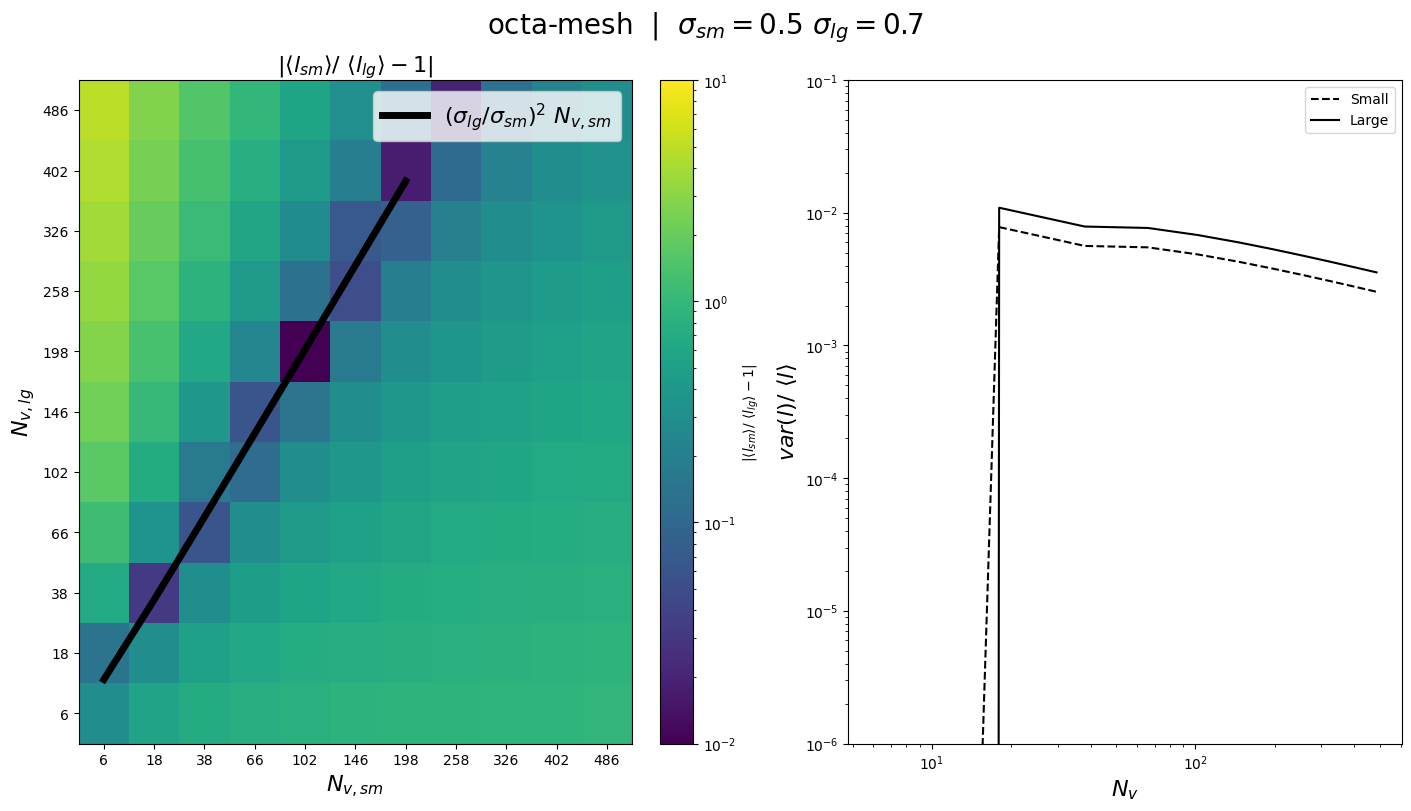

In [176]:
mesh_type = 'octa'
small_radius = 0.5
large_radius = 0.7


n = list(range(1, 12))
nv = get_vertex_counts(mesh_type, np.array(n))
diffs = np.zeros((len(n), len(n)))
vars_sm = np.zeros_like(diffs)
vars_lg = np.zeros_like(diffs)
for i, n_sm in enumerate(n):
    for j, n_lg in enumerate(n):
        l_sm, l_var_sm = get_avg_mesh_lengths(mesh_type, n_sm, small_radius)
        l_lg, l_var_lg = get_avg_mesh_lengths(mesh_type, n_lg, large_radius)
        diffs[i, j] = np.abs(l_sm / l_lg - 1)
        vars_sm[i, j] = l_var_sm / l_sm
        vars_lg[i, j] = l_var_lg / l_lg

idx = np.arange(len(nv))

cmap = plt.cm.viridis
# norm = plt.Normalize(1e-2, 5)
diff_norm = LogNorm(1e-2, 10)

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(14, 8))

# ax[0].imshow(diffs, cmap=cmap, norm=diff_norm)
# ax[0].pcolormesh(np.log2(nv), np.log2(nv), diffs.T, cmap=cmap, norm=diff_norm)
ax[0].pcolormesh(n, n, diffs.T, cmap=cmap, norm=diff_norm)
T = get_subdivision_counts(mesh_type, nv * (large_radius / small_radius) ** 2)
ax[0].plot(np.array(n)[T <= max(n)], T[T <= max(n)], c='k', lw=5, label=r'$(\sigma_{lg}/\sigma_{sm})^2\ N_{v,sm}$')
ax[0].set_title(r'$|\langle l_{sm} \rangle /\ \langle l_{lg} \rangle - 1|$', fontsize=16)
ax[0].set_xticks(n)
ax[0].set_yticks(n)
ax[0].set_xticklabels(nv)
ax[0].set_yticklabels(nv)
ax[0].set_xlabel(r'$N_{v,sm}$', fontsize=16)
ax[0].set_ylabel(r'$N_{v,lg}$', fontsize=16)
ax[0].legend(fontsize=16)
# ax[1].imshow((vars_sm + vars_lg) / 2)
ax[1].plot(nv, vars_sm[:, 0], label='Small', c='k', ls='--')
ax[1].plot(nv, vars_lg[0], label='Large', c='k')
ax[1].legend()
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$N_v$', fontsize=16)
ax[1].set_ylabel(r'$var(l) /\ \langle l \rangle$', fontsize=16)
ax[1].set_ylim(1e-6, 1e-1)

plt.suptitle(fr'{mesh_type}-mesh  |  $\sigma_{{sm}}={small_radius}\ \sigma_{{lg}}={large_radius}$', fontsize=20)

sm = plt.cm.ScalarMappable(norm=diff_norm, cmap=cmap)
sm.set_array(diffs.ravel())
cbar = plt.colorbar(sm, ax=ax[0], label=r'$|\langle l_{sm} \rangle /\ \langle l_{lg} \rangle - 1|$')

plt.savefig(f'figures/mesh/{mesh_type}-mesh-details.png', dpi=600)

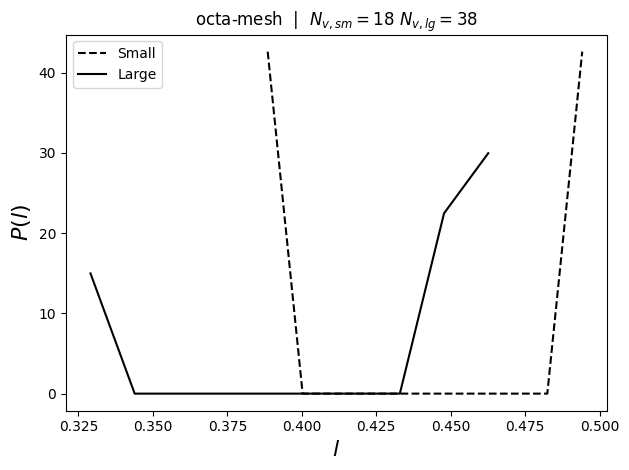

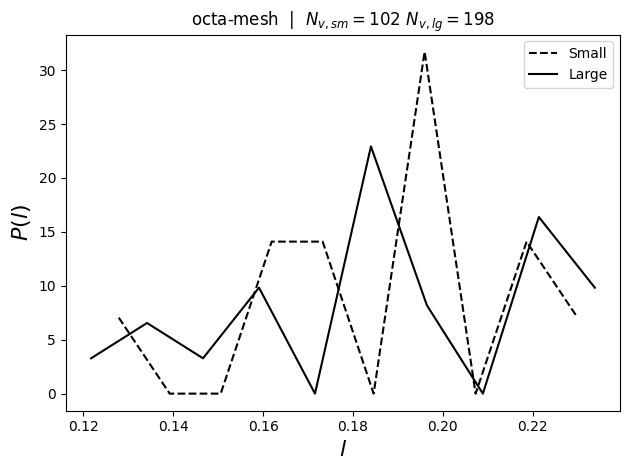

In [177]:
if mesh_type == 'tetra':
    pairs = [[10, 20], [52, 100]]
elif mesh_type == 'octa':
    pairs = [[18, 38], [102, 198]]
elif mesh_type == 'ico':
    pairs = [[42, 92], [252, 492]]
else:
    raise ValueError(f'Error: mesh_type {mesh_type} not supported.  Must be one of "tetra", "octa", "ico"')

aspect_ratio = [1.0, 1.0, 1.0]

for pair in pairs:
    pts_for_hist = []
    tri_for_hist = []
    for target_num_vertices, particle_radius in zip(pair, [small_radius, large_radius]):
        if mesh_type == 'tetra':
            n_tetra = int(np.maximum(np.round(np.sqrt((target_num_vertices - 2) / 2)), 1))
            pts, tri = meshzoo.tetra_sphere(n_tetra)
        elif mesh_type == 'octa':
            n_octa = int(np.maximum(np.round(np.sqrt((target_num_vertices - 2) / 4)), 1))
            pts, tri = meshzoo.octa_sphere(n_octa)
        elif mesh_type == 'ico':
            n_ico = int(np.maximum(np.round(np.sqrt((target_num_vertices - 2) / 10)), 1))
            pts, tri = meshzoo.icosa_sphere(n_ico)
        else:
            raise ValueError(f'Error: mesh_type {mesh_type} not supported.  Must be one of "tetra", "octa", "ico"')
        pts = np.asarray(pts, dtype=float) * particle_radius
        tri = np.asarray(tri, dtype=int)
        pts_for_hist.append(pts)
        tri_for_hist.append(tri)
        m = trimesh.Trimesh(vertices=pts, faces=tri, process=False)
        m.apply_scale(aspect_ratio)

        V = np.asarray(m.vertices)
        F = np.asarray(m.faces)

        fig = go.Figure(data=[
            go.Mesh3d(
                x=V[:, 0], y=V[:, 1], z=V[:, 2],
                i=F[:, 0], j=F[:, 1], k=F[:, 2],
                color="lightgray",
                opacity=1.0,
                flatshading=True,
                lighting=dict(ambient=0.4, diffuse=0.8, specular=0.2, roughness=0.8),
            )
        ])

        fig.update_layout(
            scene=dict(aspectmode="data"),
            margin=dict(l=0, r=0, t=0, b=0),
        )
        size = 'small' if particle_radius == 0.5 else 'large'
        fig.write_image(f"figures/mesh-examples/{size}/{mesh_type}-nv-{pts.shape[0]}.png", width=1200, height=1200, scale=2)
        plt.close()
    for pts, tri, label, ls in zip(pts_for_hist, tri_for_hist, ['Small', 'Large'], ['--', '-']):
        lengths, count, order = unique_triangle_edge_lengths(pts, tri)
        p, bin_edges = np.histogram(
            lengths.flatten(),
            weights=np.concatenate([np.ones(lengths.shape[1]) * c for c in count]),
            density=True
        )
        l = (bin_edges[1:] + bin_edges[:-1]) / 2
        plt.plot(l, p, label=label, ls=ls, c='k')
    plt.legend()
    plt.xlabel(r'$l$', fontsize=16)
    plt.ylabel(r'$P(l)$', fontsize=16)
    plt.title(fr'{mesh_type}-mesh  |  $N_{{v,sm}}={pts_for_hist[0].shape[0]}\ N_{{v,lg}}={pts_for_hist[1].shape[0]}$')
    plt.tight_layout()
    plt.savefig(f"figures/mesh-examples/{mesh_type}-nv_small-{pts.shape[0]}.png", dpi=300)
    plt.show()

In [178]:
asperity_radius = 0.12
target_num_vertices = 38

asperity_mesh = trimesh.creation.icosphere(2, asperity_radius)

if mesh_type == 'tetra':
    n_tetra = int(np.maximum(np.round(np.sqrt((target_num_vertices - 2) / 2)), 1))
    pts, tri = meshzoo.tetra_sphere(n_tetra)
elif mesh_type == 'octa':
    n_octa = int(np.maximum(np.round(np.sqrt((target_num_vertices - 2) / 4)), 1))
    pts, tri = meshzoo.octa_sphere(n_octa)
elif mesh_type == 'ico':
    n_ico = int(np.maximum(np.round(np.sqrt((target_num_vertices - 2) / 10)), 1))
    pts, tri = meshzoo.icosa_sphere(n_ico)
else:
    raise ValueError(f'Error: mesh_type {mesh_type} not supported.  Must be one of "tetra", "octa", "ico"')
pts = np.asarray(pts, dtype=float) * (small_radius - asperity_radius)
tri = np.asarray(tri, dtype=int)
m = trimesh.Trimesh(vertices=pts, faces=tri, process=False)
m.apply_scale(aspect_ratio)

asperities = [m]
for v in m.vertices:
    asperities.append(trimesh.Trimesh(vertices=asperity_mesh.vertices + v, faces=asperity_mesh.faces))

fig = go.Figure()
V = np.asarray(m.vertices)
F = np.asarray(m.faces)

fig.add_trace(go.Mesh3d(
    x=V[:, 0], y=V[:, 1], z=V[:, 2],
    i=F[:, 0], j=F[:, 1], k=F[:, 2],
    color="lightgray",
    opacity=1.0,
    flatshading=True,
    lighting=dict(ambient=0.4, diffuse=0.8, specular=0.2, roughness=0.8),
))
fig.update_layout(scene=dict(aspectmode="data"), margin=dict(l=0, r=0, t=0, b=0))
fig.write_image(f"figures/construction-example/mesh-{mesh_type}-nv-{pts.shape[0]}.png", width=1200, height=1200, scale=2)
fig.show()

fig = go.Figure()
for mesh in asperities:
    V = np.asarray(mesh.vertices)
    F = np.asarray(mesh.faces)

    fig.add_trace(go.Mesh3d(
        x=V[:, 0], y=V[:, 1], z=V[:, 2],
        i=F[:, 0], j=F[:, 1], k=F[:, 2],
        color="lightgray",
        opacity=1.0,
        flatshading=True,
        lighting=dict(ambient=0.4, diffuse=0.8, specular=0.2, roughness=0.8),
    ))
fig.update_layout(scene=dict(aspectmode="data"), margin=dict(l=0, r=0, t=0, b=0))
fig.write_image(f"figures/construction-example/final-{mesh_type}-nv-{pts.shape[0]}.png", width=1200, height=1200, scale=2)
fig.show()

In [119]:
V = np.asarray(m.vertices)
F = np.asarray(m.faces)

fig = go.Figure(data=[
    go.Mesh3d(
        x=V[:, 0], y=V[:, 1], z=V[:, 2],
        i=F[:, 0], j=F[:, 1], k=F[:, 2],
        color="lightgray",
        opacity=1.0,
        flatshading=True,
        lighting=dict(ambient=0.4, diffuse=0.8, specular=0.2, roughness=0.8),
    )
])

fig.update_layout(
    scene=dict(aspectmode="data"),
    margin=dict(l=0, r=0, t=0, b=0),
)
fig.show()

In [118]:
n_steps = 10
asperity_radius = (np.arange(1, n_steps) / n_steps) * small_radius
((large_radius - asperity_radius) / (small_radius - asperity_radius)) ** 2

array([ 2.08641975,  2.25      ,  2.46938776,  2.77777778,  3.24      ,
        4.        ,  5.44444444,  9.        , 25.        ])